In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_style("whitegrid")

In [2]:
BASE_DIR = Path.cwd().parent

PROCESSED_DIR = BASE_DIR / "data" / "processed"

fund_df = pd.read_csv(PROCESSED_DIR / "clean_fund_master.csv")
nav_df = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv")
aum_df = pd.read_csv(PROCESSED_DIR / "clean_aum.csv")
sip_df = pd.read_csv(PROCESSED_DIR / "clean_sip.csv")
category_df = pd.read_csv(PROCESSED_DIR / "clean_category.csv")
folio_df = pd.read_csv(PROCESSED_DIR / "clean_folio.csv")
txn_df = pd.read_csv(PROCESSED_DIR / "clean_transactions.csv")
holdings_df = pd.read_csv(PROCESSED_DIR / "clean_holdings.csv")
benchmark_df = pd.read_csv(PROCESSED_DIR / "clean_benchmark.csv")

In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

aum_df["date"] = pd.to_datetime(aum_df["date"])

sip_df["month"] = pd.to_datetime(sip_df["month"])

category_df["month"] = pd.to_datetime(category_df["month"])

folio_df["month"] = pd.to_datetime(folio_df["month"])

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

holdings_df["portfolio_date"] = pd.to_datetime(
    holdings_df["portfolio_date"]
)

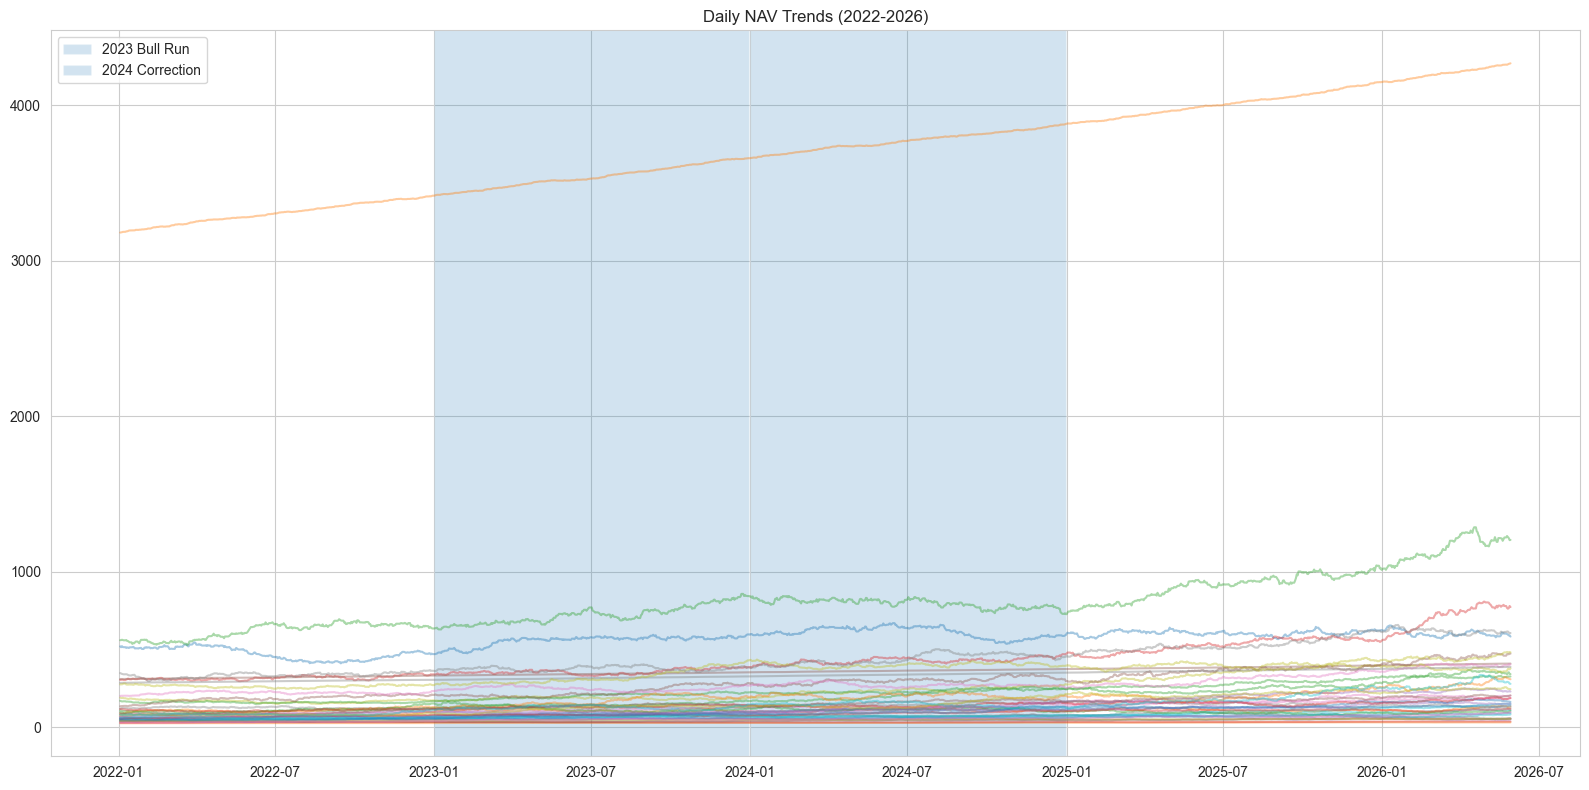

<Figure size 640x480 with 0 Axes>

In [ ]:
nav_plot = nav_df.merge(
    fund_df[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

plt.figure(figsize=(16,8))

for code in nav_df["amfi_code"].unique():
    temp = nav_df[nav_df["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], alpha=0.4)

plt.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.2,
    label="2023 Bull Run"
)

plt.axvspan(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-12-31"),
    alpha=0.2,
    label="2024 Correction"
)

plt.title("Daily NAV Trends (2022-2026)")
plt.legend()
plt.tight_layout()

plt.savefig(
    BASE_DIR / "reports/charts/nav_trend.png",
    bbox_inches="tight"
)

plt.show()


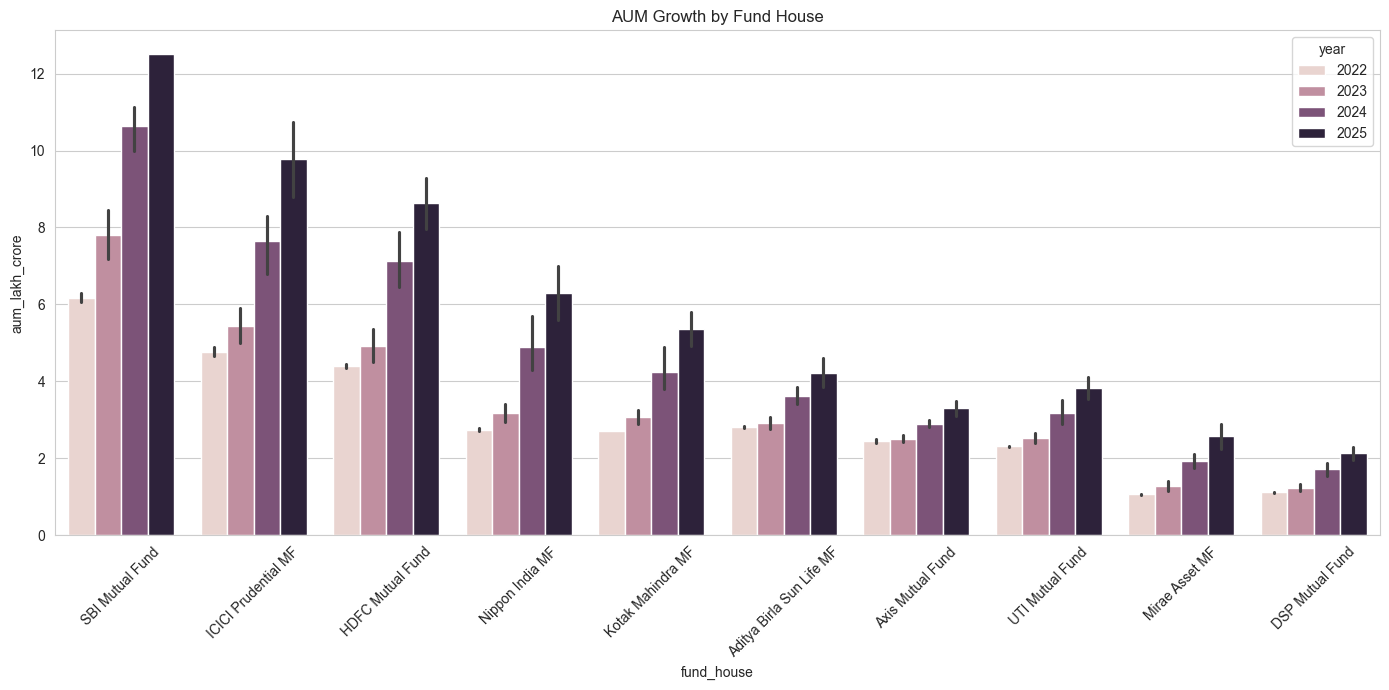

<Figure size 640x480 with 0 Axes>

In [9]:
aum_df["year"] = aum_df["date"].dt.year

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_df,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House")

plt.tight_layout()
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/AUM_Growth.png",
    bbox_inches="tight"
)

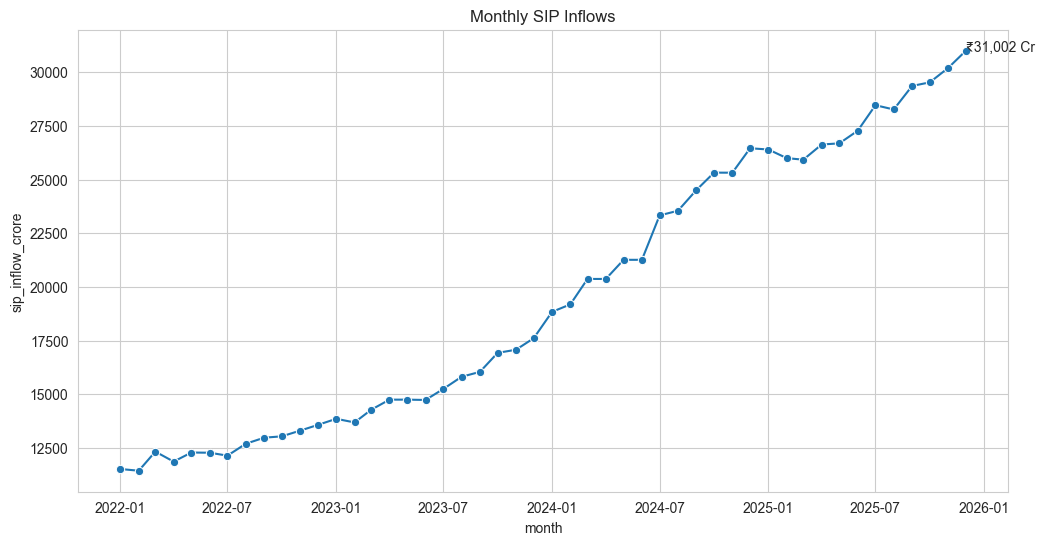

In [5]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=sip_df,
    x="month",
    y="sip_inflow_crore",
    marker="o"
)

plt.annotate(
    "₹31,002 Cr",
    xy=(sip_df["month"].max(), 31002)
)

plt.title("Monthly SIP Inflows")

plt.savefig(
    BASE_DIR / "reports/charts/sip_trend.png",
    bbox_inches="tight"
)

plt.show()

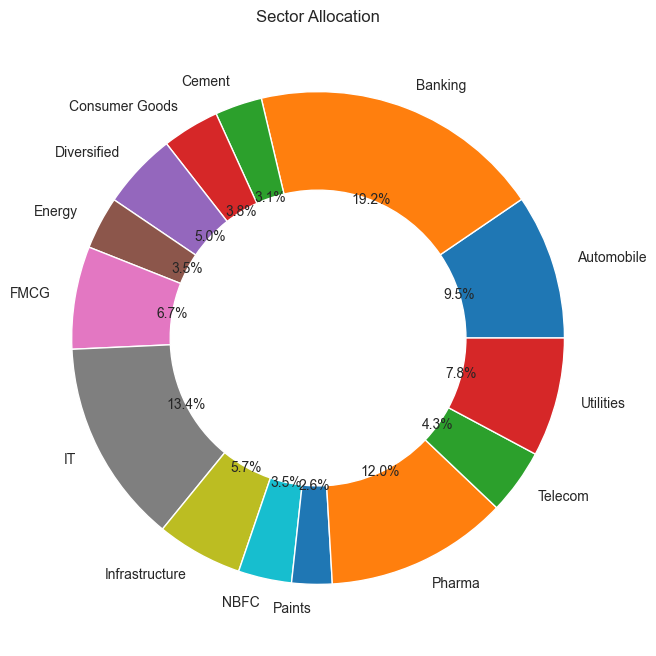

In [7]:
sector_data = (
    holdings_df.groupby("sector")
    ["weight_pct"]
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation")

plt.savefig(
    BASE_DIR / "reports/charts/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

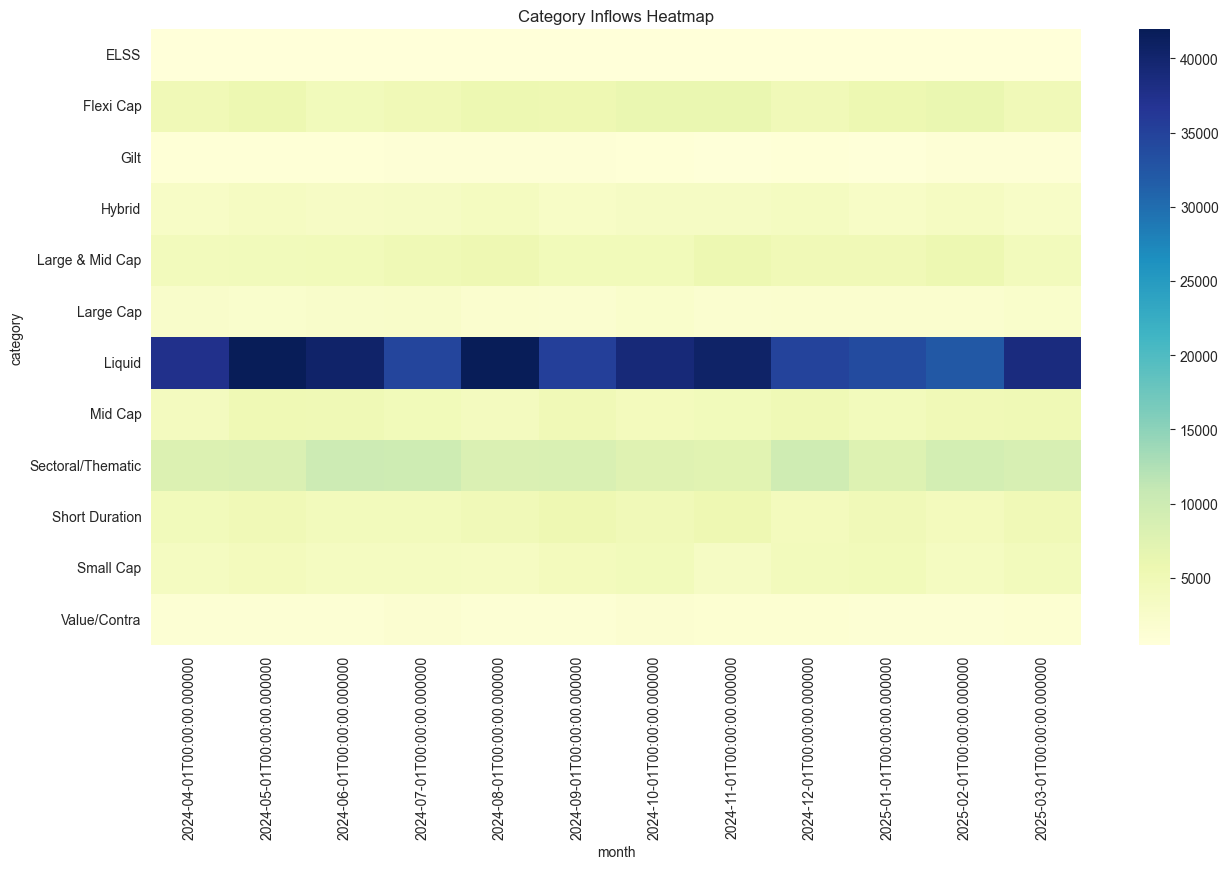

<Figure size 640x480 with 0 Axes>

In [10]:
heatmap_df = category_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu"
)

plt.title("Category Inflows Heatmap")
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/category_inflows.png",
    bbox_inches="tight"
)

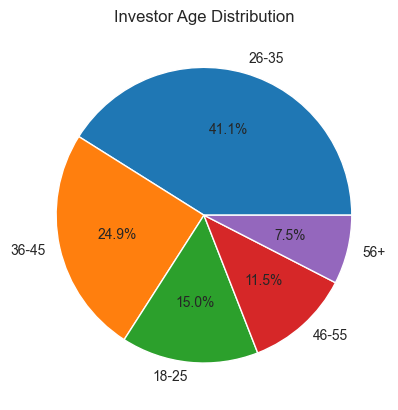

<Figure size 640x480 with 0 Axes>

In [11]:
txn_df["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/investor_age_distribution.png",
    bbox_inches="tight"
)

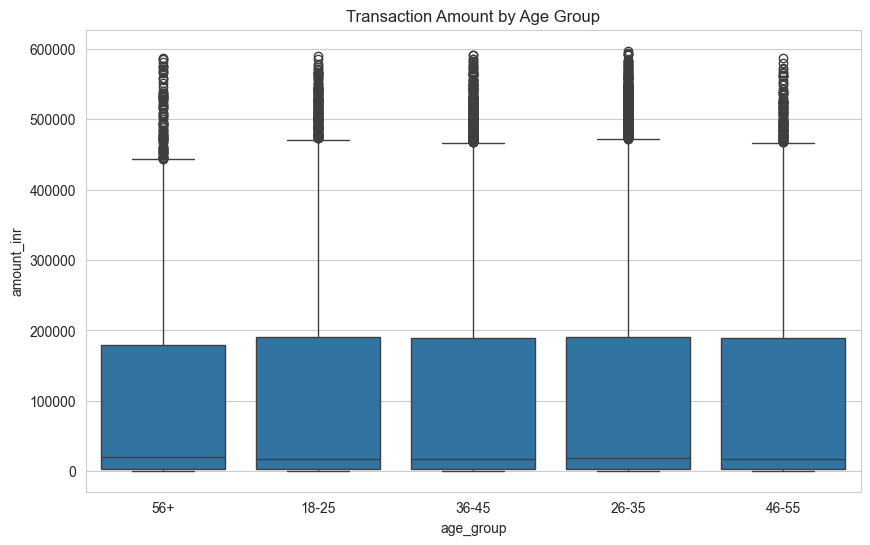

<Figure size 640x480 with 0 Axes>

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=txn_df,
    x="age_group",
    y="amount_inr"
)

plt.title("Transaction Amount by Age Group")
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/transaction_amount_by_age_group.png",
    bbox_inches="tight"
)

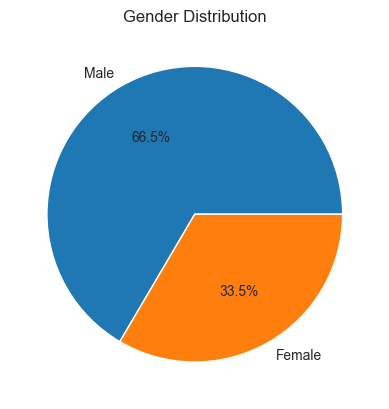

<Figure size 640x480 with 0 Axes>

In [13]:
txn_df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/gender_distribution.png",
    bbox_inches="tight"
)

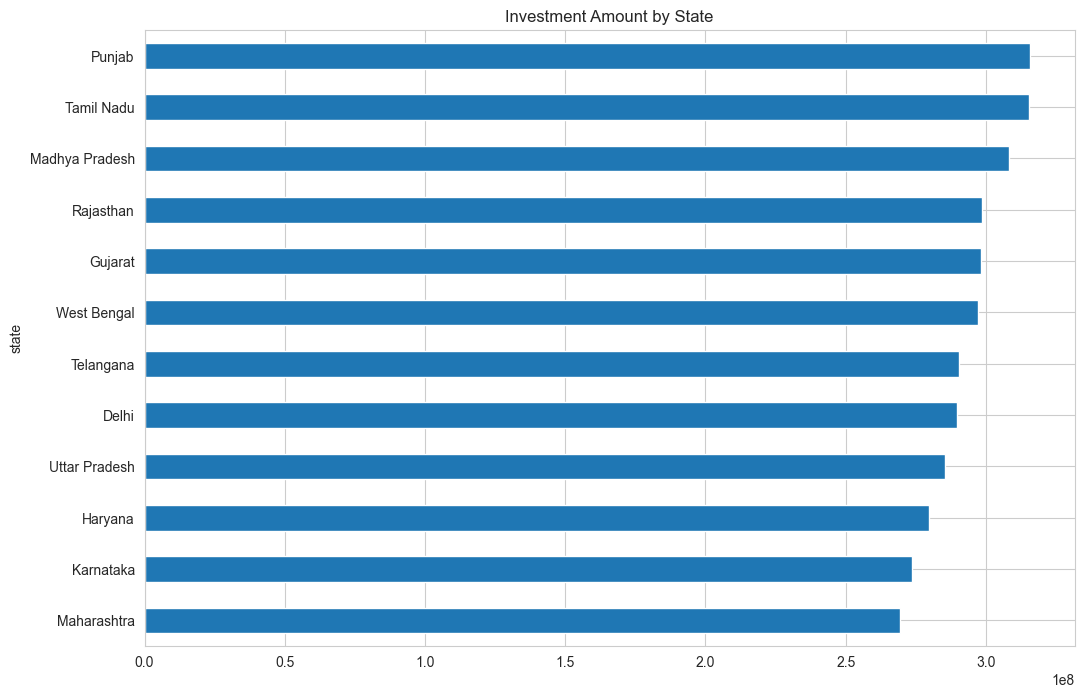

<Figure size 640x480 with 0 Axes>

In [14]:
state_data = (
    txn_df.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("Investment Amount by State")
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/investment_amount_by_state.png",
    bbox_inches="tight"
)

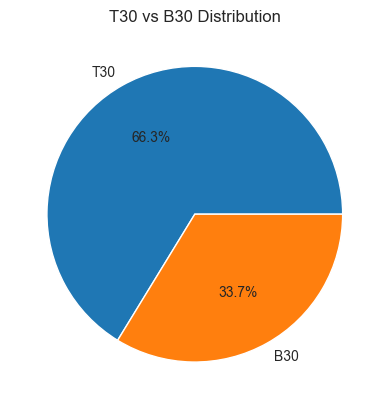

<Figure size 640x480 with 0 Axes>

In [15]:
txn_df["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/city_tier_distribution.png",
    bbox_inches="tight"
)

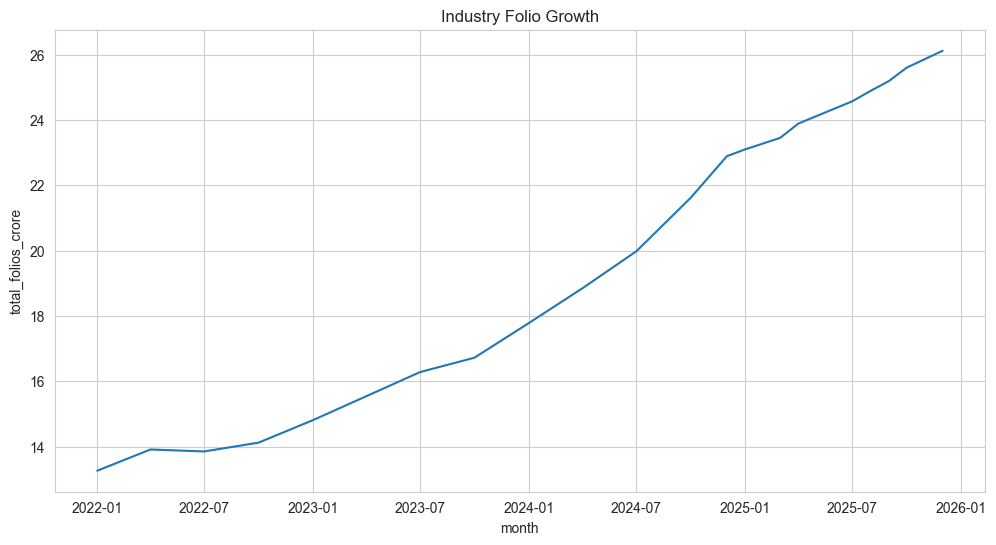

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio_df,
    x="month",
    y="total_folios_crore"
)

plt.title("Industry Folio Growth")
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/folio_growth.png",
    bbox_inches="tight"
)

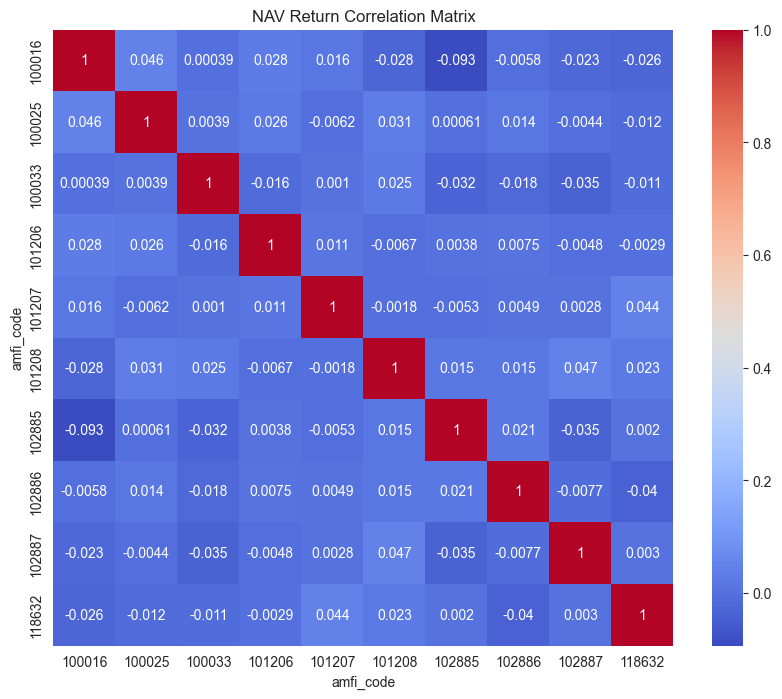

<Figure size 640x480 with 0 Axes>

In [17]:
top10 = nav_df["amfi_code"].unique()[:10]

corr_df = nav_df[
    nav_df["amfi_code"].isin(top10)
]

pivot = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/nav_return_correlation_matrix.png",
    bbox_inches="tight"
)

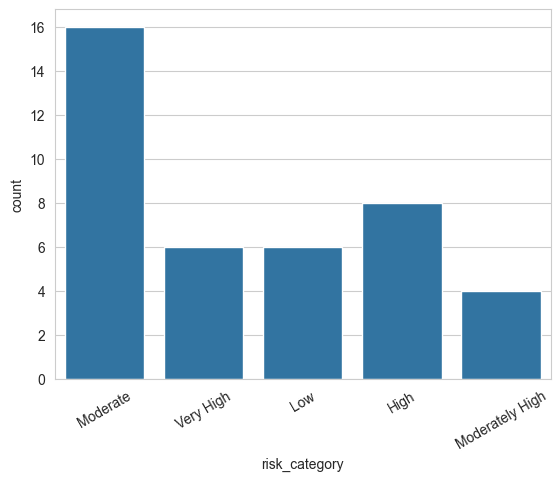

<Figure size 640x480 with 0 Axes>

In [19]:
sns.countplot(
    data=fund_df,
    x="risk_category"
)

plt.xticks(rotation=30)
plt.show()

plt.savefig(
    BASE_DIR /
    "reports/charts/risk_category_distribution.png",
    bbox_inches="tight"
)